In [ ]:
#imports
import torch
from torch import nn
from torch.nn import functional as F
from torchvision import datasets, transforms
from matplotlib import pyplot as plt

# Hyper Parameters
input_dim = 23

# TASK:  Tune latent dimension between between [3, 6, 10]
latent_dim = 6
epoch = 10
batch_size = 16
lr = 1e-4


device = "cuda:0" if torch.cuda.is_available() else "cpu"

def vis(data):
    labels_map = {
        0: "T-Shirt",
        1: "Trouser",
        2: "Pullover",
        3: "Dress",
        4: "Coat",
        5: "Sandal",
        6: "Shirt",
        7: "Sneaker",
        8: "Bag",
        9: "Ankle Boot",
    }
    figure = plt.figure(figsize=(8, 8))
    cols, rows = 3, 3
    for i in range(1, cols * rows + 1):
        sample_idx = torch.randint(len(data), size=(1,)).item()
        img, label = data[sample_idx]
        figure.add_subplot(rows, cols, i)
        plt.title(labels_map[label])
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap="gray")
    plt.show()

def compare(x_hat, x):
  figure = plt.figure(figsize=(4,8))

  figure.add_subplot(1,2,1)
  plt.imshow(x_hat[0].squeeze(), cmap="gray")

  figure.add_subplot(1,2,2)
  plt.imshow(x[0].squeeze(), cmap="gray")
  plt.show()

class VariationalEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim

        # Define conv1 as 2D convolution output channel=8, kernel size =3, stride =2
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, stride=2)
        # Define conv2 as 2D convolution output channel=16, kernel size =3, stride =2
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, stride=2)
        # Define conv3 as 2D convolution output channel=32, kernel size =3, stride =2
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, stride=2)

        # Define linear layer for means , output features is self.latent_dim
        self.fc_mu = nn.Linear(in_features = 128, out_features = self.latent_dim)

        # Define linear layer for variance , output features is self.latent_dim
        self.fc_var = nn.Linear(in_features = 128, out_features = self.latent_dim)

        self.N = torch.distributions.Normal(torch.tensor(0.0).to(device), torch.tensor(1.0).to(device))


    def forward(self, x):
        # Write Forward, Add ReLU Activation after every 2D Convolution layer
        # Forward conv1 and ReLU
        x = F.relu(self.conv1(x))
        # Forward conv2 and ReLU
        x = F.relu(self.conv2(x))

        # Forward Conv3, ReLU
        x = F.relu(self.conv3(x))

        # Reshape the output from [B,32,H,W] to [B, 32*H*W] ; B=batch_size,  H,W = height and width
        # Note H, W as this will be used in decoder architecture

        x = torch.flatten(x, 1)

        # for x through fc_mu and fc_var to get mu and var
        mu = self.fc_mu(x)
        var = self.fc_var(x)
        sig = torch.exp(0.5*var)
        z = mu + sig * self.N.sample(mu.size()).to(mu.device) # sample from normal distribution N(mu,sigma)
        kl = torch.sum(-torch.log(sig) + (torch.pow(mu, 2) + torch.pow(sig, 2) - 1) / 2, [0, 1])  # Compute KL divergence between q(z|x) and p(z)
        return z, kl / batch_size


# TASK: Define Encoder Architecture here
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim

        # Define conv1 as 2D convolution output channel=8, kernel size =3, stride =2
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, stride=2)
        # Define conv2 as 2D convolution output channel=16, kernel size =3, stride =2
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, stride=2)
        # Define conv3 as 2D convolution output channel=32, kernel size =3, stride =2
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, stride=2)
        # TASK: Figure out the input dimension to following linear layer whose output features dimension is latent_dim
        self.linear = nn.Linear(in_features=128, out_features = self.latent_dim)

    def forward(self, x):
        # Write Forward, Add ReLU Activation after every 2D Convolution layer
        # Forward conv1 and ReLU
        x = F.relu(self.conv1(x))
        # Forward conv2 and ReLU
        x = F.relu(self.conv2(x))

        # Forward Conv3, ReLU
        x = F.relu(self.conv3(x))
        # Reshape the output from [B,32,H,W] to [B, 32*H*W] ; B=batch_size,  H,W = height and width
        # Note H, W as this will be used in decoder architecture
        x = torch.flatten(x, 1)
        # Tensor here should be of shape [B, 32*H*W]
        # Forward through linear layer and pass through sigmoid activation
        x = torch.sigmoid(self.linear(x))
        return (x)

# TASK: Define decoder Architecture here
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        # Define linear layer input features =latent, output features = C*H*W , see encoder forward pass
        self.fc1 = nn.Linear(in_features = latent_dim, out_features = 128)
        # define upconv1 as 2D Transposed convolution , input channels = 32, output channels= 16, kernel size = 3, stride = 2
        # see API of nn.ConvTranspose2d for more info on this
        self.upconv1 = nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2)
        # define upconv2 as 2D Transposed convolution ,  output channels= 8, kernel size = 3, stride = 2
        self.upconv2 = nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2)

        # define upconv3 as 2D Transposed convolution ,  output channels= 1, kernel size = 3, stride = 2
        self.upconv3 = nn.ConvTranspose2d(8, 1, kernel_size=3, stride=2)

    def forward(self, x):
        # forward throg fc1 and relu
        x = F.relu(self.fc1(x))

        # Reshape x from [B, 32*H*W] to [B, 32, H, W], figure out values of H and W from encoder's conv3 layer output
        x = x.view(-1, 32, 2, 2)

        # Forward through upconv1 and ReLU
        x = F.relu(self.upconv1(x))
        # Forward through upconv2 and ReLU
        x = F.relu(self.upconv2(x))
        # Forward through upconv3 and ReLU
        x = F.relu(self.upconv3(x))

        return x


class AE_class(nn.Module):
    def __init__(self, VE_, DE_):
        super().__init__()
        self.VE = VE_
        self.DE = DE_

    def forward(self, x):
        x = self.VE(x)
        x_hat = self.DE(x)
        return x_hat


class VAE_class(nn.Module):
    def __init__(self, VE_, DE_):
        super().__init__()
        self.VE = VE_
        self.DE = DE_

    def forward(self, x):
        x, kl = self.VE(x)

        x_hat = self.DE(x)
        return x_hat, kl # add this kl to loss

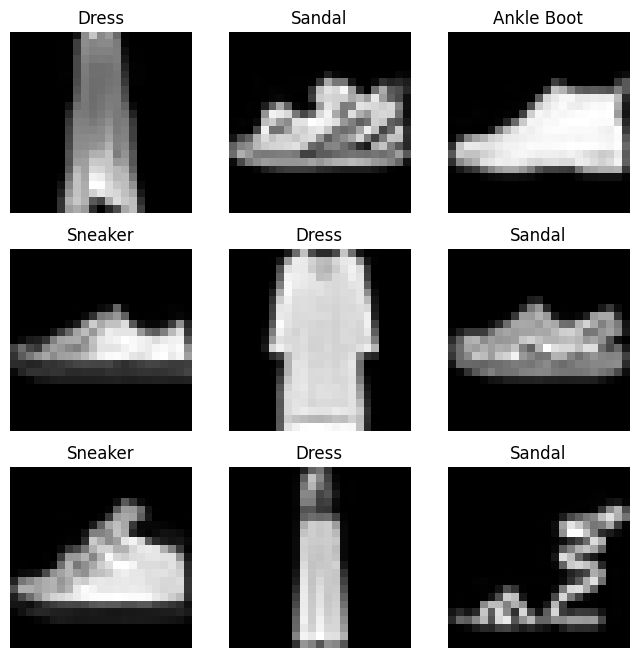

In [ ]:
#dataset
# TASK: Add two Transform composing resize and ToTensor()
trans = transforms.Compose([
    # from transforms add resize transform here
    # from transforms add ToTensor() transform here
    transforms.Resize((23, 23)),
    transforms.ToTensor(),
    ])

training_data = datasets.FashionMNIST(
    root="./data",
    train=True,
    # download=True,
    transform=trans
)

training_data, validation_data = torch.utils.data.random_split(training_data, lengths=[int(0.8*len(training_data)), int(0.2*len(training_data))])

# Create Training dataloader here with batch_size variable at line 14 and shuffle=True
training_dataloader = torch.utils.data.DataLoader(training_data, batch_size=batch_size, shuffle=True)

# Create Validation dataloader here with batch_size  variable at line 14 and shuffle=True
validation_dataloader = torch.utils.data.DataLoader(validation_data, batch_size=batch_size, shuffle=True)

test_data = datasets.FashionMNIST(
    root="./data",
    train=False,
    # download=True,
    transform=trans
)

# Create Test dataloader here with batch_size  variable at line 14 and shuffle=True
test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

# Visualize
vis(training_data)



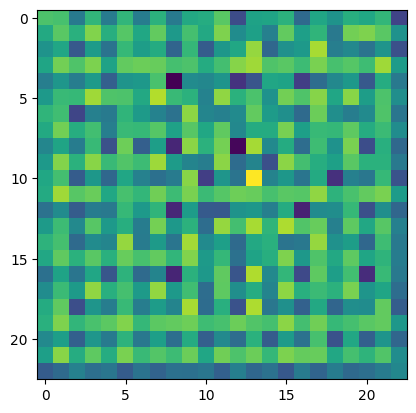

Epoch: 0


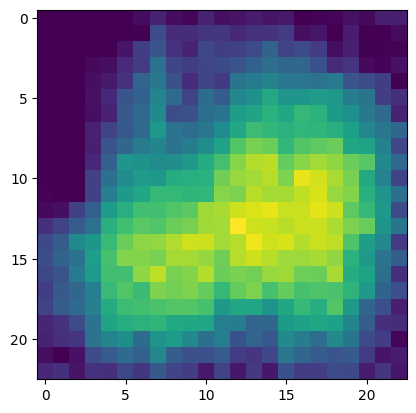

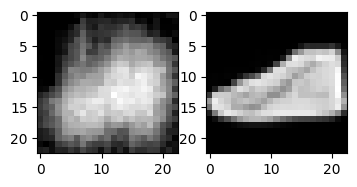

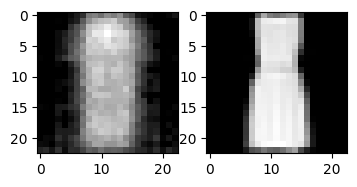

0.07424523017182946
Epoch: 1


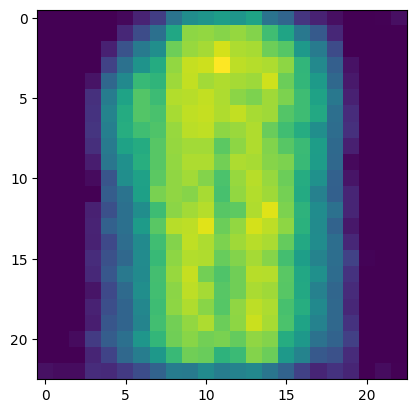

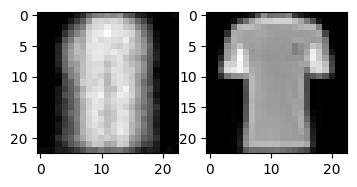

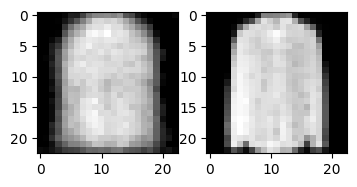

0.05912786554296812
Epoch: 2


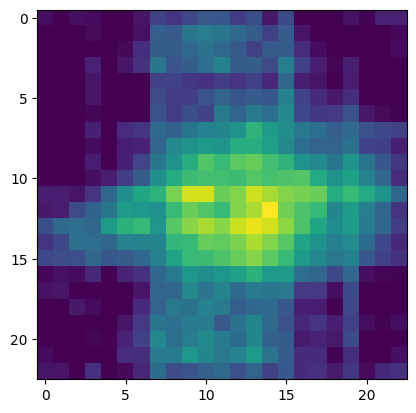

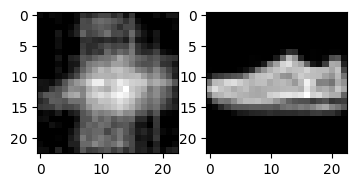

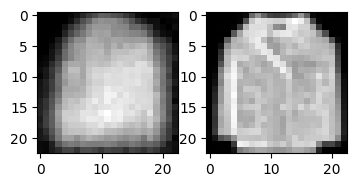

0.05690165350710352
Epoch: 3


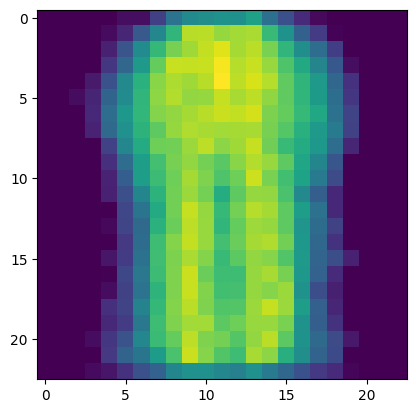

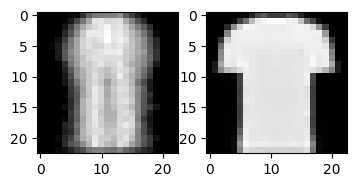

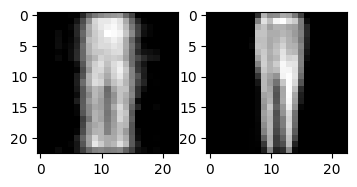

0.05581607999528448
Epoch: 4


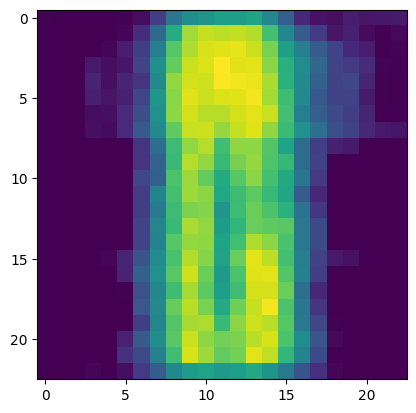

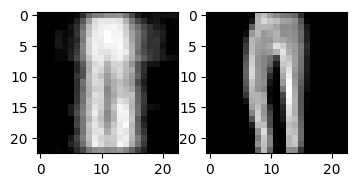

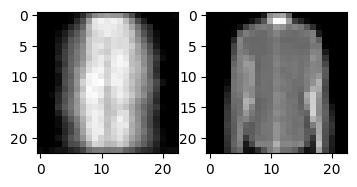

0.05535023159409563
Epoch: 5


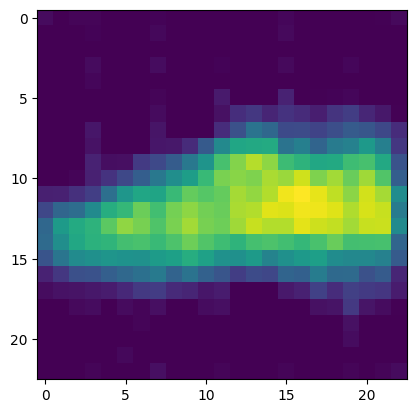

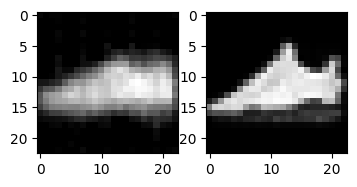

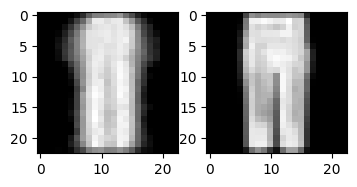

0.05492339179168145
Epoch: 6


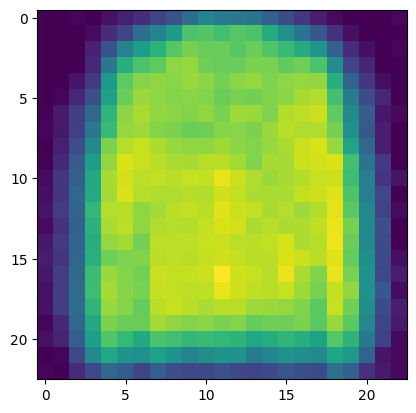

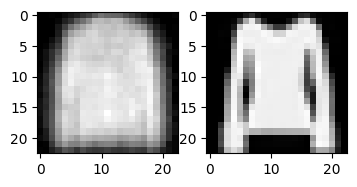

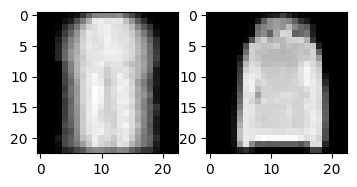

0.05461133894448479
Epoch: 7


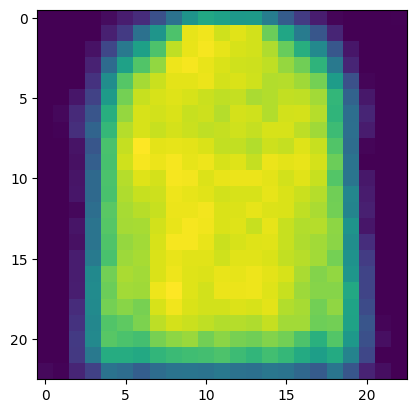

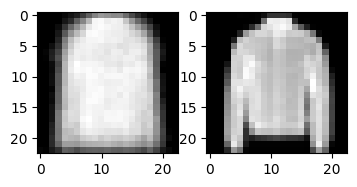

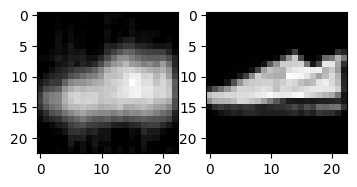

0.05440293370435635
Epoch: 8


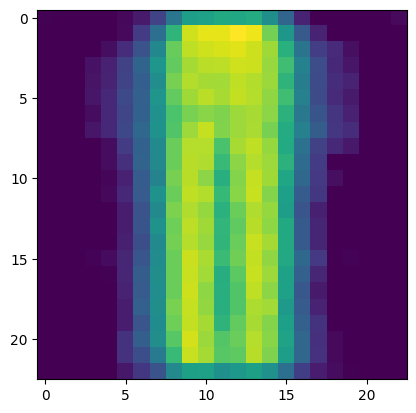

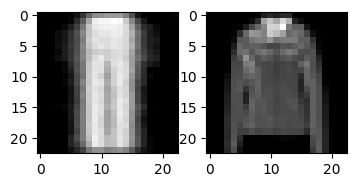

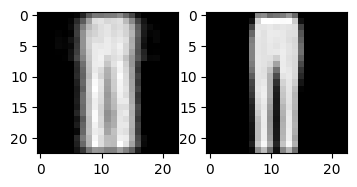

0.054203634491811196
Epoch: 9


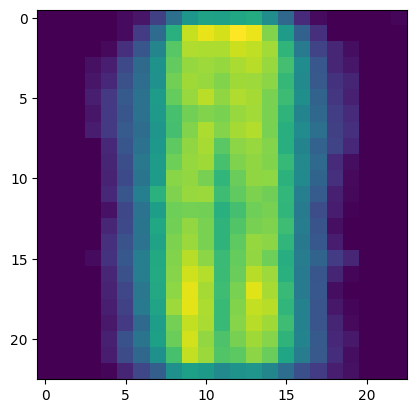

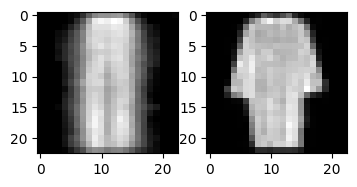

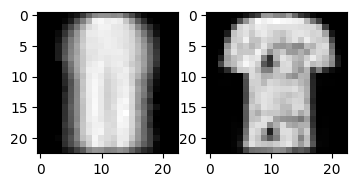

0.05409079958871007


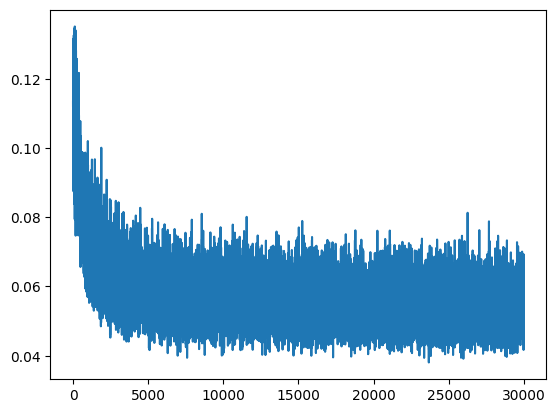

In [ ]:
E = VariationalEncoder(latent_dim) # Get Encoder Network
D = Decoder(latent_dim) # Get Decoder Network
AE = VAE_class(E, D).to(device) # Create full network compsing of Encoder and Decoder

plt.imshow(AE(torch.randn((batch_size, 1, 23, 23)).to(device))[0][0][0].detach().cpu())
plt.show()
# training loop VAE
# TASK : Try MSE loss and later BCE loss
loss = nn.MSELoss(reduction="mean")
# loss = nn.BCELoss(reduction="sum")

# TASK: Get Adam optimizer with parameters of AE at line 94 and lr at line 15
optimizer = torch.optim.Adam(AE.parameters(), lr=lr)

AE.to(device)
loss_history = []
beta=1e-2

for e in range(epoch):
    running_loss = 0
    print("Epoch:", e)
    for batch in training_dataloader:
        optimizer.zero_grad()
        batch = batch[0].to(device)

        outputs, kl = AE(batch)

        lss = loss(outputs, batch)
        new_lss = lss + (beta * kl)
        new_lss.backward()
        optimizer.step()
        running_loss += new_lss.item()
        loss_history.append(new_lss.item())

    # Training Loop
    # -Iterate of train dataloader
    #   - transfer batched images to device
    #   - get reconscrusted images
    #   - get loss from reconstructed and original images
    #   - clear stale gradients
    #   - backprop
    #   - update params
    #   - Accumulate loss in running loss for printing at end of epoch (see line 132)
    #   - Append loss to loss history for visualization at line 135



    for y, _ in test_dataloader:
        # print(y.shape)
        y = y.to(device)
        y_hat = AE(y)[0].detach().cpu()

        for i in range(2):
            compare(y_hat[i], y[i].cpu())
        break









    print(running_loss/(len(training_dataloader)))

# Visualize reconstructions
plt.plot(loss_history)
plt.show()


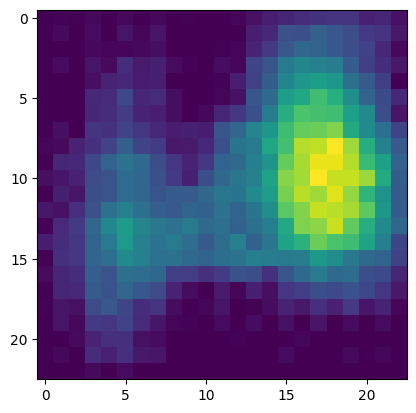

In [ ]:
plt.imshow(D(torch.randn((1, latent_dim)).to(device))[0][0].detach().cpu())

In [ ]:

E = Encoder(latent_dim) # Get Encoder Network
D = Decoder(latent_dim) # Get Decoder Network
AE = AE_class(E, D) # Create full network compsing of Encoder and Decoder

plt.imshow(AE(torch.randn((batch_size, 1, 23, 23)))[0][0].detach())
plt.show()
# training loop VAE
# TASK : Try MSE loss and later BCE loss
loss = nn.MSELoss(reduction="mean")
# loss = nn.BCELoss(reduction="sum")

# TASK: Get Adam optimizer with parameters of AE at line 94 and lr at line 15
optimizer = torch.optim.Adam(AE.parameters(), lr=lr)

AE.to(device)
loss_history = []

for e in range(epoch):
    running_loss = 0
    print("Epoch:", e)
    for batch in training_dataloader:
        optimizer.zero_grad()
        batch = batch[0].to(device)

        outputs = AE(batch)
        lss = loss(outputs, batch)
        lss.backward()
        optimizer.step()
        running_loss += lss.item()
        loss_history.append(lss.item())

    # Training Loop
    # -Iterate of train dataloader
    #   - transfer batched images to device
    #   - get reconscrusted images
    #   - get loss from reconstructed and original images
    #   - clear stale gradients
    #   - backprop
    #   - update params
    #   - Accumulate loss in running loss for printing at end of epoch (see line 132)
    #   - Append loss to loss history for visualization at line 135





    for y, _ in test_dataloader:
        # print(y.shape)
        y = y.to(device)
        y_hat = AE(y).detach().cpu()
        for i in range(2):
            compare(y_hat[i], y[i].cpu())
        break







    print(running_loss/(len(training_dataloader)))

# Visualize reconstructions
plt.plot(loss_history)
plt.show()

